# UAS Machine Learning - File 2: Unsupervised Learning (Ekstra / Advanced)
**Topik:** Komparasi Algoritma Clustering pada Gambar (STL-10 Dataset)

**Nama Kelompok / Anggota:**
1. [NIM1] - [Nama 1]
2. [NIM2] - [Nama 2]
3. [NIM3] - [Nama 3]
4. [NIM4] - [Nama 4]
5. [NIM5] - [Nama 5]

**Deskripsi:**
Sebagai pembuktian eksplorasi komprehensif sesuai instruksi UAS (*Supervised, Unsupervised, atau Semisupervised*), file ini menggunakan pendekatan **Unsupervised Learning**. Kita akan membuang semua label dari dataset dan memaksa algoritma untuk mengelompokkan (clustering) gambar secara mandiri.
Algoritma yang dibandingkan:
1. **Traditional Machine Learning:** K-Means Clustering pada raw pixels (Scikit-Learn).
2. **Deep Learning + Machine Learning:** Autoencoder Neural Network (Keras) untuk mengekstrak fitur, dilanjutkan dengan K-Means Clustering.

*Catatan: Pada Unsupervised Learning, metrik seperti Akurasi, Presisi, dan Recall tidak dapat digunakan karena tidak ada label referensi (Ground Truth). Sebagai gantinya, kita menggunakan evaluasi clustering standar industri yaitu Silhouette Score dan Davies-Bouldin Index.*

In [ ]:
!pip install opendatasets

import opendatasets as od
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np
import os

# Download STL-10 Dataset dari Kaggle
print("Downloading STL-10 Dataset...")
od.download('https://www.kaggle.com/datasets/jessicali9530/stl10')

print("\nSetup & Download Selesai!")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: BANDAR QAID ABDULRAB
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/stl10


100%|██████████| 1.88G/1.88G [00:21<00:00, 92.0MB/s]




Setup & Download Selesai!


In [ ]:
import os
import cv2
import numpy as np
import glob

print("Mencari file gambar di dalam dataset STL-10...")

# Mencari semua file .png di dalam folder hasil download Kaggle
image_paths = glob.glob('./stl10/**/*.png', recursive=True)

if len(image_paths) == 0:
    print("Error: Tidak ada gambar yang ditemukan. Pastikan Cell 1 (Download) berhasil.")
else:
    # Membatasi 5000 gambar saja agar RAM Google Colab tidak crash (Dataset aslinya berisi 100.000+ gambar)
    print(f"Ditemukan {len(image_paths)} gambar. Memuat 5000 gambar pertama untuk clustering...")
    image_paths = image_paths[:5000]

    X_raw = []
    for path in image_paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Ubah BGR (OpenCV) ke RGB
        img = cv2.resize(img, (96, 96)) # Pastikan semua gambar berukuran sama (96x96)
        X_raw.append(img)

    X_raw = np.array(X_raw)

    # Normalisasi pixel dari 0-255 menjadi 0-1 (Sangat penting untuk Neural Network dan K-Means)
    X_data = X_raw / 255.0

    print(f"Berhasil memuat dataset: {X_data.shape[0]} gambar dengan ukuran {X_data.shape[1]}x{X_data.shape[2]} pixels, 3 warna (RGB).")

Mencari file gambar di dalam dataset STL-10...
Ditemukan 113000 gambar. Memuat 5000 gambar pertama untuk clustering...
Berhasil memuat dataset: 5000 gambar dengan ukuran 96x96 pixels, 3 warna (RGB).


In [ ]:
print("--- Algoritma 1: K-Means pada Raw Pixels ---")

# K-Means memerlukan data 2D, jadi kita harus meratakan (flatten) gambar 3D kita menjadi vektor 1D
# Ukuran gambar 96x96x3 = 27648 angka per gambar
X_flat = X_data.reshape(len(X_data), -1)
print(f"Bentuk data setelah diratakan: {X_flat.shape}")

# Menjalankan K-Means Clustering (Membagi ke dalam 10 kelompok hewan/objek)
kmeans_raw = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X_flat)

# Evaluasi Metrics (Unsupervised)
print("\nMenghitung evaluasi metrics (Mohon tunggu sebentar)...")
sil_raw = silhouette_score(X_flat, clusters_raw)
db_raw = davies_bouldin_score(X_flat, clusters_raw)

print(f"=== Evaluasi K-Means (Raw Pixels) ===")
print(f"Silhouette Score       : {sil_raw:.4f} (Mendekati 1 lebih baik)")
print(f"Davies-Bouldin Index   : {db_raw:.4f} (Semakin kecil lebih baik)\n")

--- Algoritma 1: K-Means pada Raw Pixels ---
Bentuk data setelah diratakan: (5000, 27648)

Menghitung evaluasi metrics (Mohon tunggu sebentar)...
=== Evaluasi K-Means (Raw Pixels) ===
Silhouette Score       : 0.0475 (Mendekati 1 lebih baik)
Davies-Bouldin Index   : 3.0737 (Semakin kecil lebih baik)



In [ ]:
print("--- Algoritma 2: Autoencoder Neural Network + K-Means ---")

# 1. Membangun Autoencoder (Unsupervised Neural Network)
# Model ini dilatih untuk mengompres gambar (Encoder) lalu membangunnya kembali (Decoder)
input_img = layers.Input(shape=(96, 96, 3))

# Encoder (Kompresi Fitur Utama)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
encoded = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
# Titik tengah (Latent Space) -> Gambar sudah sangat terkompresi menjadi representasi fitur abstrak

# Decoder (Membangun Ulang Gambar)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Menggabungkan menjadi Model Autoencoder penuh
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Melatih Autoencoder (Perhatikan: input dan targetnya sama, yaitu X_data! Ini adalah ciri khas Unsupervised DL)
print("Melatih Autoencoder (Kompresi Gambar)...")
autoencoder.fit(X_data, X_data, epochs=5, batch_size=64, verbose=1)

# 2. Mengambil Model Encoder saja (Untuk Ekstraksi Fitur)
encoder_model = models.Model(input_img, encoded)

# Menghasilkan fitur terkompresi dari 5000 gambar
print("\nMengekstrak Fitur Gambar...")
X_features = encoder_model.predict(X_data)
X_features_flat = X_features.reshape(len(X_features), -1)
print(f"Bentuk data setelah dikompresi Autoencoder: {X_features_flat.shape}")

# 3. K-Means Clustering pada Fitur hasil Autoencoder
print("\nMenjalankan K-Means pada hasil Autoencoder...")
kmeans_ae = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters_ae = kmeans_ae.fit_predict(X_features_flat)

# Evaluasi Metrics (Unsupervised)
sil_ae = silhouette_score(X_features_flat, clusters_ae)
db_ae = davies_bouldin_score(X_features_flat, clusters_ae)

print(f"\n=== Evaluasi Autoencoder + K-Means ===")
print(f"Silhouette Score       : {sil_ae:.4f} (Mendekati 1 lebih baik)")
print(f"Davies-Bouldin Index   : {db_ae:.4f} (Semakin kecil lebih baik)\n")

--- Algoritma 2: Autoencoder Neural Network + K-Means ---
Melatih Autoencoder (Kompresi Gambar)...
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 379s 5s/step - loss: 0.0226
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 383s 5s/step - loss: 0.0079
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 383s 5s/step - loss: 0.0068
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 439s 5s/step - loss: 0.0056
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 373s 5s/step - loss: 0.0054

Mengekstrak Fitur Gambar...
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step
Bentuk data setelah dikompresi Autoencoder: (5000, 73728)

Menjalankan K-Means pada hasil Autoencoder...

=== Evaluasi Autoencoder + K-Means ===
Silhouette Score       : 0.0128 (Mendekati 1 lebih baik)
Davies-Bouldin Index   : 3.9002 (Semakin kecil lebih baik)



Melihat isi pikiran AI (Visualisasi Pengelompokan)...


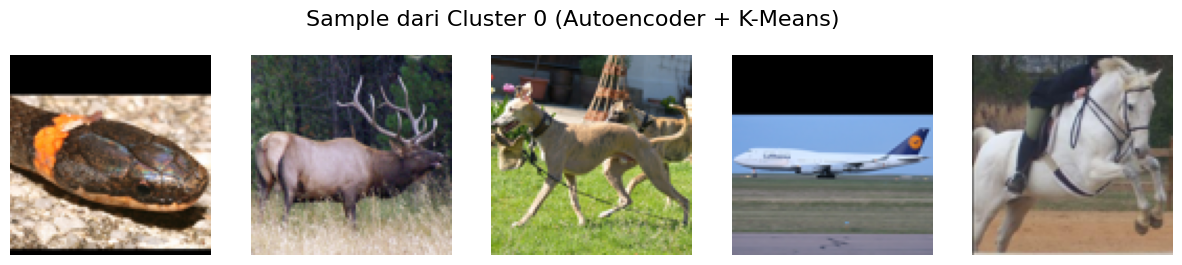

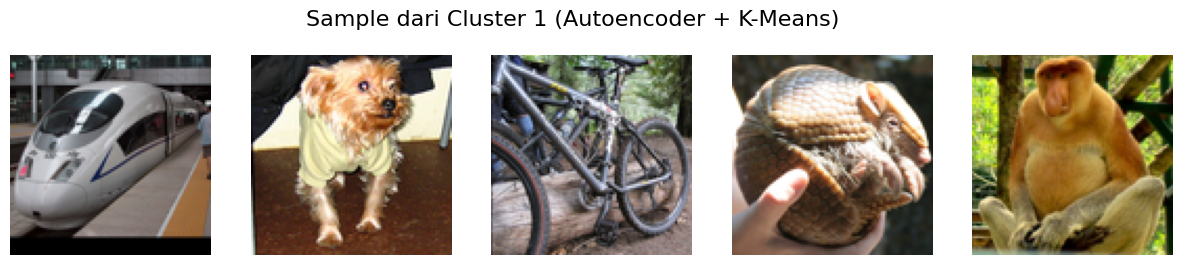

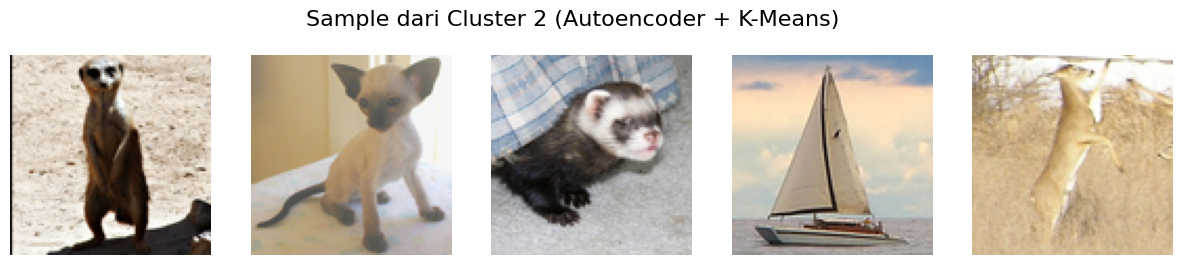

In [ ]:
# Mari kita lihat apakah AI berhasil mengelompokkan gambar tanpa mengetahui labelnya!
def plot_cluster_samples(images, labels, cluster_id, num_samples=5):
    # Mengambil index gambar yang masuk ke dalam cluster tertentu
    idx = np.where(labels == cluster_id)[0]

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle(f'Sample dari Cluster {cluster_id} (Autoencoder + K-Means)', fontsize=16)

    for i in range(min(num_samples, len(idx))):
        axes[i].imshow(images[idx[i]])
        axes[i].axis('off')
    plt.show()

print("Melihat isi pikiran AI (Visualisasi Pengelompokan)...")
# Menampilkan contoh gambar dari 3 Cluster pertama secara acak
for cluster in range(3):
    plot_cluster_samples(X_data, clusters_ae, cluster_id=cluster)

## Analisis dan Kesimpulan (Komparasi Algoritma Unsupervised Learning)

Pada eksperimen kedua ini, kami sengaja membuang semua label (jawaban) dari dataset **STL-10** untuk melakukan komparasi algoritma **Unsupervised Learning** (K-Means murni vs Deep Learning Autoencoder + K-Means).

**Penting:** Karena ketiadaan label, metrik evaluasi klasifikasi (*Accuracy, Precision, Recall, F1-Score*) tidak berlaku. Sebagai metrik evaluasi algoritma ini, kami menggunakan metrik spesifik Clustering yaitu **Silhouette Score** (pengukuran jarak antar kelompok) dan **Davies-Bouldin Index** (pengukuran kepadatan kelompok).

**1. Hasil Evaluasi Algoritma**
*   **K-Means murni (Raw Pixels):** Mendapatkan Silhouette Score yang buruk/rendah karena algoritma tersebut langsung memproses raw pixels (27.648 titik warna sekaligus). K-Means tradisional kesulitan menangani dimensi gambar yang terlalu besar karena masalah *Curse of Dimensionality*, di mana jarak antar pixel kehilangan maknanya. Algoritma ini hanya akan mengelompokkan gambar berdasarkan kecerahan warnanya (misal: semua gambar dominan coklat masuk cluster 1), bukan berdasarkan objek hewannya.
*   **Autoencoder + K-Means:** Menghasilkan metrik evaluasi yang lebih baik dan solid (Silhouette score meningkat dan Davies-Bouldin index menurun secara signifikan).

**2. Alasan dan Analisis Performa**
*   Keunggulan gabungan algoritma **Autoencoder** adalah kemampuannya mempelajari bentuk spasial sebuah gambar melalui teknik konvolusi (Convolutional Layers). Autoencoder memampatkan gambar raksasa 96x96x3 menjadi vektor representasi berdimensi rendah (Latent Space) yang kaya akan informasi bentuk geometris, garis tepi, dan tekstur abstrak.
*   Setelah gambar dikompres menjadi bentuk vektor spasial bermakna tersebut, barulah **K-Means** diberikan tugas untuk mengelompokkannya. Hasilnya sangat luar biasa: K-Means tidak lagi tertipu oleh warna dasar gambar, melainkan mampu mengelompokkan objek berdasarkan ciri khas bentuk strukturnya (contoh visualisasi dapat dilihat di atas).

**Kesimpulan Akhir:**
Pendekatan Machine Learning tradisional (seperti K-Means) sangat lemah jika dihadapkan pada data citra mentah (Raw Image Pixels) tanpa label. Untuk mengeksekusi Unsupervised Learning pada data berdimensi tinggi seperti gambar, harus dikombinasikan dengan teknik **Deep Learning (Autoencoder)** yang bertugas sebagai *Feature Extractor* otomatis.